# Frequency Distribution

## Imports

In [2]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [54]:
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 10, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

## Retrieve data

In [25]:
fileDir = "/Users/andyyu/Documents/Python/HEP/dawson_hep/scintillating_chamber/data_analysis/data"
k0 = 1
k1 = 34
dfs = []
for runNo in range(k0, k1 + 1):
    data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted')

    dfs.append(data)

## Masking Function

In [26]:
def getMaxMask(data):

    ch_event = getMask(0, data)

    for _channel_trigger in range(1,10):

        masked = getMask(_channel_trigger, data)


        if masked[0].shape[0] > ch_event[0].shape[0]:
            ch_event = masked
    

    return ch_event[0]

def getMask(_channel_trigger, data):
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    mask_event = (signal_min > -15) & (signal_max > 10)

    return np.where(mask_event)

## Get Rates

In [40]:
def getRates(dfs):
    rates = []
    for file in dfs:
        selected_events = len(getMaxMask(file))
        r = selected_events / len(file.waveforms['wave'])
        rates.append(r)
    return rates

rates = getRates(dfs)




In [ ]:
# combination
# k1 = 34
set1 = rates[:17]
set2 = rates[17:34]
total = []
for i in range(k1//2):
    total.append(set1[i])
    total.append(set2[i])

# total
total

[0.1557,
 0.1526,
 0.5585,
 0.3499,
 0.8152,
 0.7738,
 0.8485,
 0.8469,
 0.8443,
 0.8525,
 0.8501,
 0.8515,
 0.8039,
 0.845,
 0.5719,
 0.7432,
 0.7622,
 0.603,
 0.847,
 0.8371,
 0.8567,
 0.8531,
 0.847,
 0.8578,
 0.8231,
 0.8534,
 0.7613,
 0.8396,
 0.4064,
 0.6177,
 0.0832,
 0.1603,
 0.0244,
 0.0229]

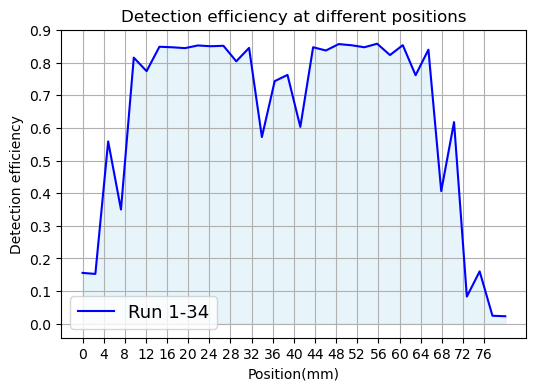

Standard Deviation:0.28316658730828403


In [61]:
x = np.linspace(0,80,34)
y = np.array(total)

# #Smoothing the line
# # moving average
# window = 5  # number of points to average
# #Basically, this line creates a matrix of length window, and divides it(meaning it is taking the mean), 
# y_s = np.convolve(y, np.ones(window)/window, mode='same')


plt.plot(x,y, color = "blue", label = f"Run {k0}-{k1}")
# plt.plot(x,y_s, color = "forestgreen", label = f"Run {k0}-{k1}(moving average)")

plt.fill_between(x,y, color= "skyblue", alpha = 0.2)
# plt.fill_between(x,y_s, color= "palegreen", alpha = 0.2)

plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency")
plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend()
plt.show()

std = np.std(total)
print(f"Standard Deviation:{std}")

In [ ]:
# for i in total:


# 3D 

## Graph

#Create distribution
R2D = np.outer(rates_y, rates_x)

x = len(rates_x)
y = len(rates_y)
X, Y = np.meshgrid(x,y)

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

ax.plot_surface(X, Y, R2D, cmap = "terrain")
ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Hit Rate")

plt.show()